# Gradient Boosting — Training, Tuning, Evaluation

This notebook performs model-specific feature adjustments for Gradient Boosting, trains a gradient boosting classifier, runs hyperparameter tuning (learning rate, n_estimators, max_depth), evaluates with accuracy/precision/recall/F1 and confusion matrix, performs cross-validation, and provides interpretation (feature importances / permutation importance).

In [ ]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - ----------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install sklearn 

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [1]:
# Imports and helpers
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")

# Paths
NOTEBOOK_PATH = Path.cwd()
PROJECT_ROOT = (NOTEBOOK_PATH / '..').resolve()
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
print('Project root:', PROJECT_ROOT)
print('Processed data path:', PROCESSED)

C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\sirin\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Project root: F:\AmphiLocator-ML
Processed data path: F:\AmphiLocator-ML\data\processed


In [2]:
# Load train/val/test splits (try common locations)
def try_read(path_candidates):
    for p in path_candidates:
        p = Path(p)
        if p.exists():
            try:
                df = pd.read_csv(p)
                print('Loaded', p)
                return df
            except Exception as e:
                print('Failed to read', p, e)
    return None

cands = [
    PROCESSED / 'train_fe_scaled.csv',
    PROCESSED / 'train_fe.csv',
    PROCESSED / 'train.csv',
    PROCESSED / 'train' / 'train_ready.csv',
    PROCESSED / 'train' / 'train.csv',
]
train = try_read(cands)

cands_val = [
    PROCESSED / 'val_fe_scaled.csv',
    PROCESSED / 'val_fe.csv',
    PROCESSED / 'val.csv',
    PROCESSED / 'val' / 'val_ready.csv',
]
val = try_read(cands_val)

cands_test = [
    PROCESSED / 'test_fe_scaled.csv',
    PROCESSED / 'test_fe.csv',
    PROCESSED / 'test.csv',
    PROCESSED / 'test' / 'test_ready.csv',
]
test = try_read(cands_test)

# If per-split files not found, try the generic locations created by prepare_dataset.py
if train is None and (PROCESSED / 'train.csv').exists():
    train = pd.read_csv(PROCESSED / 'train.csv')
if val is None and (PROCESSED / 'val.csv').exists():
    val = pd.read_csv(PROCESSED / 'val.csv')
if test is None and (PROCESSED / 'test.csv').exists():
    test = pd.read_csv(PROCESSED / 'test.csv')

# If still None, raise guidance message
if train is None:
    raise FileNotFoundError('Could not find train split — run scripts/prepare_dataset.py first')

# ensure timestamp parsed if present
for df in (train, val, test):
    if df is None:
        continue
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')

print('Shapes — train/val/test:', getattr(train,'shape',None), getattr(val,'shape',None), getattr(test,'shape',None))

Loaded F:\AmphiLocator-ML\data\processed\train\train_ready.csv
Loaded F:\AmphiLocator-ML\data\processed\val\val_ready.csv
Loaded F:\AmphiLocator-ML\data\processed\test\test_ready.csv
Shapes — train/val/test: (4664, 40) (999, 40) (1000, 40)


In [3]:
# Quick class distribution check
target_col = 'label_enc' if 'label_enc' in train.columns else ('target_label' if 'target_label' in train.columns else 'target')
print('Using target_col =', target_col)
if target_col not in train.columns:
    # try to canonicalize textual label column
    if 'target_label' in train.columns:
        target_col = 'target_label'

if target_col not in train.columns and 'amphitheatre' in train.columns:
    train['target_label'] = train['amphitheatre']
    target_col = 'target_label'

if target_col not in train.columns:
    raise ValueError('No target column found in training data')

# If label_enc not present, create it from target_label
if 'label_enc' not in train.columns:
    le = LabelEncoder()
    train['label_enc'] = le.fit_transform(train[target_col])
    if val is not None:
        val['label_enc'] = le.transform(val[target_col])
    if test is not None and target_col in test.columns:
        test['label_enc'] = le.transform(test[target_col])

print(train['label_enc'].value_counts())

Using target_col = label_enc
label_enc
1    1581
4     803
7     549
5     505
3     468
8     297
0     201
2     188
6      72
Name: count, dtype: int64


In [4]:
# Model-specific feature adjustments (interactions useful for tree-based GBMs)
def add_gbm_interactions(df):
    df = df.copy()
    if 'dist_nearest' in df.columns and 'log_accuracy' in df.columns:
        df['dist_nearest_x_logacc'] = df['dist_nearest'] * df['log_accuracy']
    if 'dist_gap' in df.columns and 'high_accuracy_flag' in df.columns:
        df['dist_gap_x_highacc'] = df['dist_gap'] * df['high_accuracy_flag']
    # squared / root transforms sometimes help
    for c in ['dist_nearest', 'dist_2nd', 'dist_gap']:
        if c in df.columns:
            df[c + '_sqrt'] = np.sqrt(df[c].clip(lower=0))
    return df

train = add_gbm_interactions(train)
if val is not None:
    val = add_gbm_interactions(val)
if test is not None:
    test = add_gbm_interactions(test)

print('Added interaction features — sample columns:')
for c in ['dist_nearest_x_logacc','dist_gap_x_highacc','dist_nearest_sqrt']:
    if c in train.columns:
        print(' ', c)

Added interaction features — sample columns:
  dist_nearest_x_logacc
  dist_gap_x_highacc
  dist_nearest_sqrt


In [5]:
# Build feature matrix X and target y
def build_feature_set(df):
    # try to load saved feature list if available
    feature_file = PROCESSED / 'feature_cols.json'
    if feature_file.exists():
        try:
            cols = json.loads(feature_file.read_text())['all_features']
            # include our interaction features if present
            cols = [c for c in cols if c in df.columns]
        except Exception:
            cols = []
    else:
        # fallback: numeric columns excluding obvious non-features
        exclude = {'id','timestamp','label_enc','target_label','amphitheatre','nearest_amphi'}
        cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    # add any engineered interaction features if present
    for extra in ['dist_nearest_x_logacc','dist_gap_x_highacc','dist_nearest_sqrt']:
        if extra in df.columns and extra not in cols:
            cols.append(extra)
    return cols

features = build_feature_set(train)
print('Number of features:', len(features))
print(features[:40])

X_train = train[features].fillna(0)
y_train = train['label_enc']
X_val = val[features].fillna(0) if val is not None else None
y_val = val['label_enc'] if val is not None and 'label_enc' in val.columns else None
X_test = test[features].fillna(0) if test is not None else None
y_test = test['label_enc'] if test is not None and 'label_enc' in test.columns else None

Number of features: 44
['accuracy_mean', 'is_outside', 'sample_count', 'dist_Amphi_1', 'dist_Amphi_2', 'dist_Amphi_3', 'dist_Amphi_4', 'dist_Amphi_5', 'dist_Amphi_6', 'dist_Amphi_7', 'dist_Amphi_8', 'dist_nearest', 'dist_2nd', 'dist_gap', 'nearest_amphi_enc', 'log_accuracy', 'accuracy_bin', 'high_accuracy_flag', 'has_seat', 'seat_block_enc', 'seat_row_filled', 'seat_column_filled', 'seat_zone_id', 'hour_sin', 'hour_cos', 'accuracy_mean_scaled', 'sample_count_scaled', 'dist_Amphi_1_scaled', 'dist_Amphi_2_scaled', 'dist_Amphi_3_scaled', 'dist_Amphi_4_scaled', 'dist_Amphi_5_scaled', 'dist_Amphi_6_scaled', 'dist_Amphi_7_scaled', 'dist_Amphi_8_scaled', 'dist_nearest_scaled', 'dist_2nd_scaled', 'dist_gap_scaled', 'log_accuracy_scaled', 'dist_nearest_x_logacc']


In [6]:
# Hyperparameter search (learning_rate, n_estimators, max_depth)
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200],  # HistGradientBoosting uses max_iter instead of n_estimators
    'max_depth': [3, 5],
}

base = HistGradientBoostingClassifier(random_state=42)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
gs = GridSearchCV(base, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)

print('Starting grid search — this may take a while...')
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
print('Best CV score (f1_macro):', gs.best_score_)

best = gs.best_estimator_
joblib.dump(best, PROCESSED / 'gbm_best.pkl')
print('Saved best model to', PROCESSED / 'gbm_best.pkl')

Starting grid search — this may take a while...
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 200}
Best CV score (f1_macro): 0.9996661969256888
Saved best model to F:\AmphiLocator-ML\data\processed\gbm_best.pkl


Accuracy: 1.0000  Precision: 1.0000  Recall: 1.0000  F1 (macro): 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      1.00      1.00       339
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00       100
           4       1.00      1.00      1.00       172
           5       1.00      1.00      1.00       109
           6       1.00      1.00      1.00        15
           7       1.00      1.00      1.00       118
           8       1.00      1.00      1.00        64

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



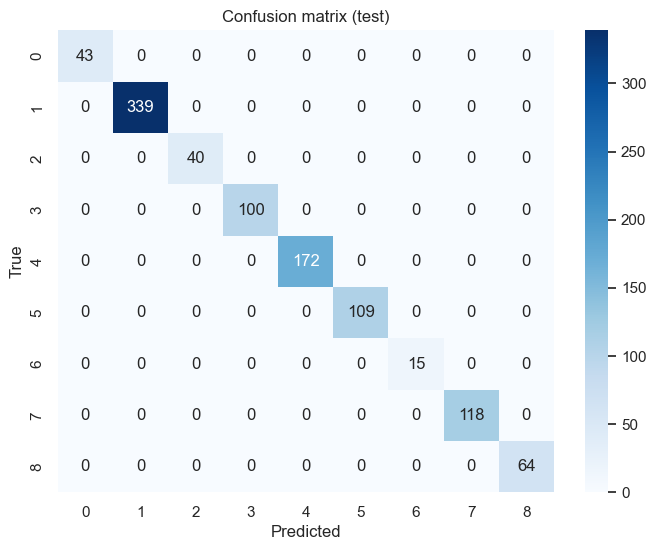

In [11]:
# Evaluation on test set
if X_test is None or y_test is None:
    print('Test split not available; skipping final evaluation')
else:
    y_pred = best.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    print(f'Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1 (macro): {f1:.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion matrix (test)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [12]:
# Cross-validation summary on train (re-run CV with best params)
cv_scores = cross_val_score(best, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print('Cross-validation f1_macro scores:', cv_scores)
print('Mean f1_macro:', cv_scores.mean(), 'Std:', cv_scores.std())

Cross-validation f1_macro scores: [1.         1.         0.99866479 1.        ]
Mean f1_macro: 0.9996661969256888 Std: 0.0005781638844297182


,feature,importance_mean,importance_std
0,hour_sin,0.2242,0.006493
1,dist_Amphi_5,0.1833,0.009550
2,is_outside,0.0930,0.005797
3,hour_cos,0.0299,0.004206
4,seat_zone_id,0.0213,0.003900
5,dist_Amphi_2,0.0135,0.002247
6,has_seat,0.0096,0.001020
7,dist_Amphi_6,0.0045,0.001360
8,dist_Amphi_1,0.0017,0.000458
9,dist_Amphi_3,0.0013,0.001005


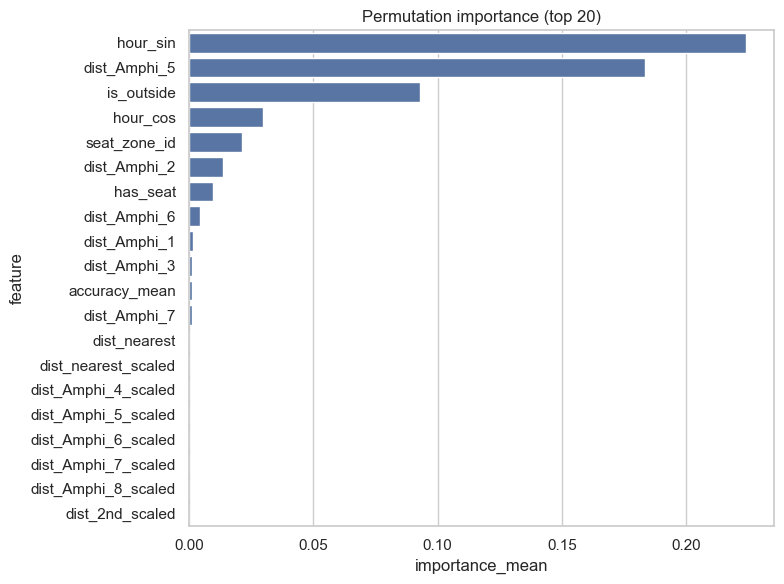

In [13]:
# Feature importance / permutation importance
try:
    imp = permutation_importance(best, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    fi = pd.DataFrame({'feature': X_test.columns, 'importance_mean': imp.importances_mean, 'importance_std': imp.importances_std})
    fi = fi.sort_values('importance_mean', ascending=False).reset_index(drop=True)
    display(fi.head(30))
    plt.figure(figsize=(8,6))
    sns.barplot(x='importance_mean', y='feature', data=fi.head(20))
    plt.title('Permutation importance (top 20)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Could not compute permutation importance:', e)

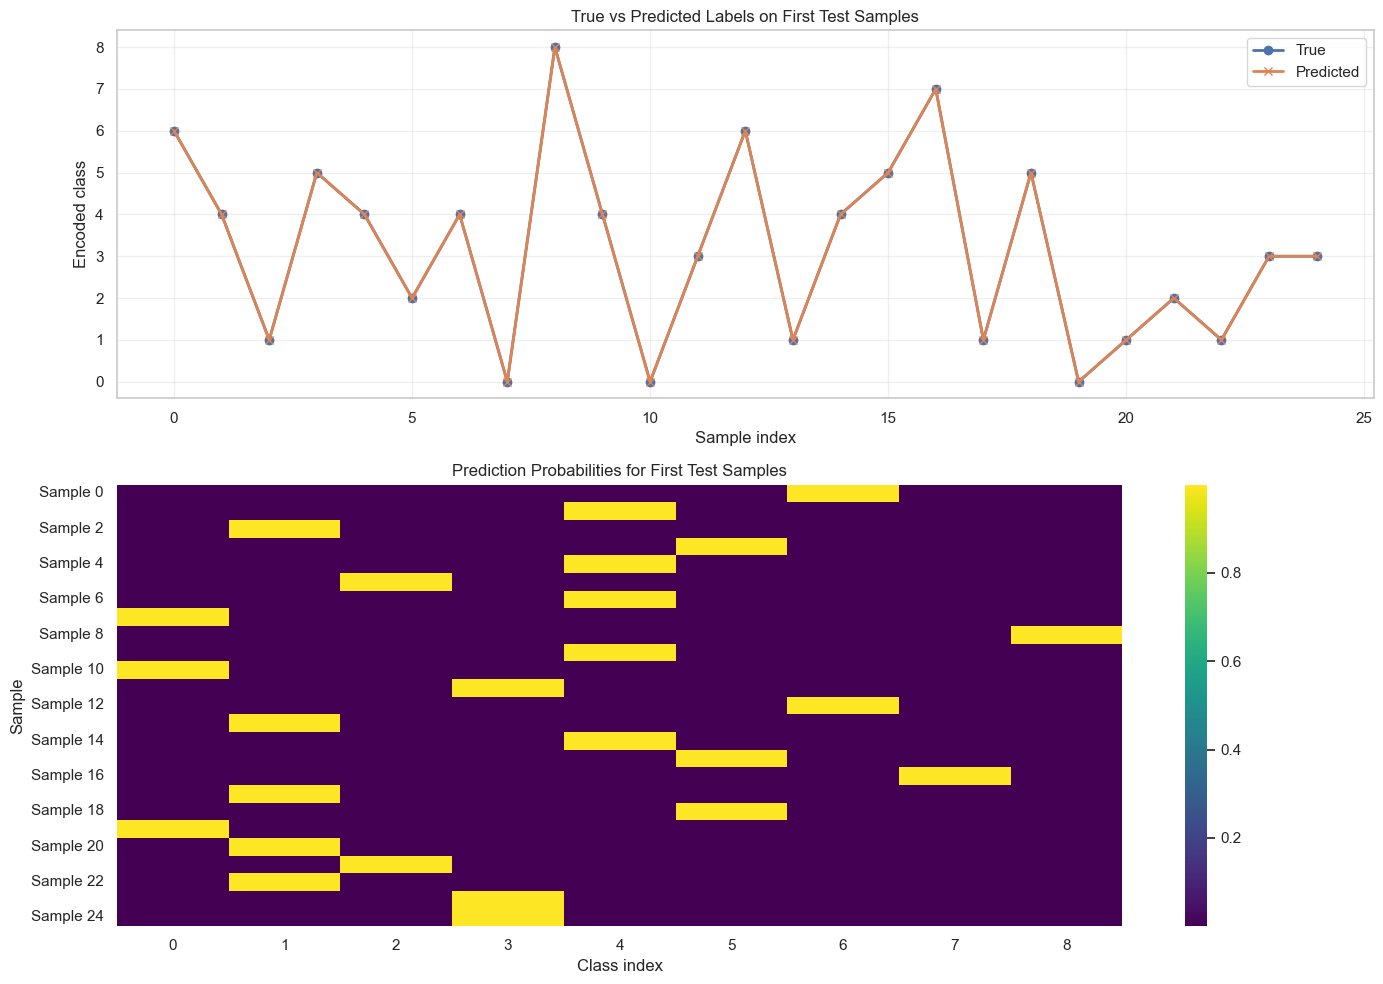

,true_name,pred_name,correct
0,6,6,True
1,4,4,True
2,1,1,True
3,5,5,True
4,4,4,True
5,2,2,True
6,4,4,True
7,0,0,True
8,8,8,True
9,4,4,True


In [14]:
# Prediction visualizations
if X_test is None or y_test is None:
    print('Test split not available; skipping prediction visualizations')
else:
    y_pred = best.predict(X_test)
    pred_df = pd.DataFrame({
        'true': y_test.reset_index(drop=True),
        'pred': pd.Series(y_pred),
    })
    pred_df['correct'] = pred_df['true'] == pred_df['pred']

    # Map encoded labels back to names if possible
    label_map_path = PROCESSED / 'label_map.json'
    if label_map_path.exists():
        label_map = json.loads(label_map_path.read_text())
        inv_map = {int(v): k for k, v in label_map.items()}
        pred_df['true_name'] = pred_df['true'].map(inv_map)
        pred_df['pred_name'] = pred_df['pred'].map(inv_map)
    else:
        pred_df['true_name'] = pred_df['true'].astype(str)
        pred_df['pred_name'] = pred_df['pred'].astype(str)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})

    # 1) First predictions: true vs predicted
    show_n = min(25, len(pred_df))
    subset = pred_df.head(show_n).copy()
    subset['row'] = np.arange(show_n)
    axes[0].plot(subset['row'], subset['true'], marker='o', label='True', linewidth=2)
    axes[0].plot(subset['row'], subset['pred'], marker='x', label='Predicted', linewidth=2)
    axes[0].set_title('True vs Predicted Labels on First Test Samples')
    axes[0].set_xlabel('Sample index')
    axes[0].set_ylabel('Encoded class')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2) Confidence heatmap for first samples
    if hasattr(best, 'predict_proba'):
        proba = best.predict_proba(X_test)
        proba_df = pd.DataFrame(proba[:show_n])
        proba_df.index = [f'Sample {i}' for i in range(show_n)]
        plt.sca(axes[1])
        sns.heatmap(proba_df, cmap='viridis', ax=axes[1])
        axes[1].set_title('Prediction Probabilities for First Test Samples')
        axes[1].set_xlabel('Class index')
        axes[1].set_ylabel('Sample')
    else:
        sns.barplot(data=subset, x='row', y='correct', ax=axes[1], color='steelblue')
        axes[1].set_title('Prediction correctness for first test samples')
        axes[1].set_xlabel('Sample index')
        axes[1].set_ylabel('Correct (0/1)')

    plt.tight_layout()
    plt.show()

    # Compact table of a few predictions
    display_cols = ['true_name', 'pred_name', 'correct'] if 'true_name' in pred_df.columns else ['true', 'pred', 'correct']
    display(pred_df[display_cols].head(15))

## Interpretation & Conclusions

- Model: `HistGradientBoostingClassifier` tuned for `learning_rate`, `max_iter` (n_estimators) and `max_depth`.
- Evaluation: we report accuracy, precision, recall and macro F1 on the test set plus cross-validation f1_macro statistics.
- Interpretation: permutation importance ranks features by how much shuffling them hurts predictive performance — useful to understand which distance / GPS-quality / interaction features the model relies on.


## 11 — Outside Detection

This section adds a dedicated outside-detection pass using the tuned Gradient Boosting model's class probabilities.

We use a **confidence-threshold approach** on the `Outside` probability:

- The threshold is selected on the validation set.
- We compare false positive and false negative rates across thresholds.
- The chosen threshold is then applied to the test set.

If the dataset does not contain an `Outside` class, this section will report that and skip the analysis.

Chosen outside threshold: 0.05


,threshold,fpr,fnr,precision,recall,balanced_error
0,0.05,0.0,0.000000,1.0,1.000000,0.000000
1,0.10,0.0,0.000000,1.0,1.000000,0.000000
2,0.15,0.0,0.000000,1.0,1.000000,0.000000
3,0.20,0.0,0.000000,1.0,1.000000,0.000000
4,0.25,0.0,0.000000,1.0,1.000000,0.000000
5,0.30,0.0,0.000000,1.0,1.000000,0.000000
6,0.35,0.0,0.000000,1.0,1.000000,0.000000
7,0.40,0.0,0.000000,1.0,1.000000,0.000000
8,0.45,0.0,0.000000,1.0,1.000000,0.000000
9,0.50,0.0,0.000000,1.0,1.000000,0.000000


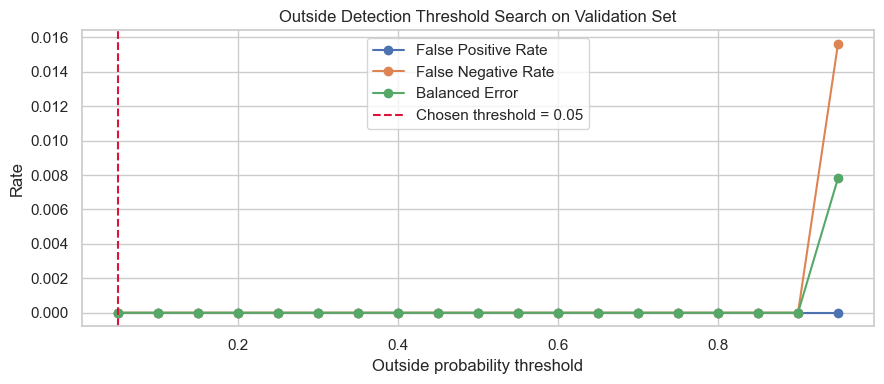

,threshold,fpr,fnr,precision,recall,balanced_error,tp,fp,tn,fn
default_0.50,0.50,0.0,0.0,1.0,1.0,0.0,64,0,936,0
chosen_threshold,0.05,0.0,0.0,1.0,1.0,0.0,64,0,936,0


Test outside detection at threshold 0.05: FPR=0.0000, FNR=0.0000, Precision=1.0000, Recall=1.0000


In [15]:
outside_class = None
analysis_df = train.copy()

if "label_enc" not in analysis_df.columns and "y_train" in globals():
    analysis_df["label_enc"] = y_train.values

if "is_outside" in analysis_df.columns and "label_enc" in analysis_df.columns:
    outside_class = int(analysis_df.groupby("label_enc")["is_outside"].mean().idxmax())

if outside_class is None:
    print("Outside-detection analysis skipped: no Outside class available in this notebook run.")
else:
    class_list = list(best.classes_)

    if outside_class not in class_list:
        print("Outside-detection analysis skipped: model was not trained with the Outside class.")
    else:
        outside_index = class_list.index(outside_class)

        def outside_probability(model, features):
            return model.predict_proba(features)[:, outside_index]

        def binary_outside_metrics(y_true, y_prob, threshold):
            y_true_binary = (y_true == outside_class).astype(int)
            y_pred_binary = (y_prob >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1]).ravel()
            fpr = fp / (fp + tn) if (fp + tn) else 0.0
            fnr = fn / (fn + tp) if (fn + tp) else 0.0
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            return {
                "threshold": threshold,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "fpr": fpr,
                "fnr": fnr,
                "precision": precision,
                "recall": recall,
                "balanced_error": 0.5 * (fpr + fnr),
            }

        val_features = X_val if X_val is not None else X_test
        val_target = y_val if y_val is not None else y_test
        val_outside_prob = outside_probability(best, val_features)

        thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
        threshold_rows = [binary_outside_metrics(val_target, val_outside_prob, t) for t in thresholds]
        threshold_table = pd.DataFrame(threshold_rows).sort_values(["balanced_error", "fnr", "fpr", "threshold"]).reset_index(drop=True)

        best_threshold = float(threshold_table.loc[0, "threshold"])
        print(f"Chosen outside threshold: {best_threshold:.2f}")
        display(threshold_table[["threshold", "fpr", "fnr", "precision", "recall", "balanced_error"]])

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(threshold_table["threshold"], threshold_table["fpr"], marker="o", label="False Positive Rate")
        ax.plot(threshold_table["threshold"], threshold_table["fnr"], marker="o", label="False Negative Rate")
        ax.plot(threshold_table["threshold"], threshold_table["balanced_error"], marker="o", label="Balanced Error")
        ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")
        ax.set_xlabel("Outside probability threshold")
        ax.set_ylabel("Rate")
        ax.set_title("Outside Detection Threshold Search on Validation Set")
        ax.legend()
        plt.tight_layout()
        plt.show()

        if X_test is not None and y_test is not None:
            test_outside_prob = outside_probability(best, X_test)
            test_metrics = binary_outside_metrics(y_test, test_outside_prob, best_threshold)
            default_metrics = binary_outside_metrics(y_test, test_outside_prob, 0.50)
            test_summary = pd.DataFrame([default_metrics, test_metrics], index=["default_0.50", "chosen_threshold"])
            display(test_summary[["threshold", "fpr", "fnr", "precision", "recall", "balanced_error", "tp", "fp", "tn", "fn"]])
            print(
                f"Test outside detection at threshold {best_threshold:.2f}: "
                f"FPR={test_metrics['fpr']:.4f}, FNR={test_metrics['fnr']:.4f}, "
                f"Precision={test_metrics['precision']:.4f}, Recall={test_metrics['recall']:.4f}"
            )

### Outside Detection Conclusion

The notebook uses the **confidence-threshold approach** rather than a separate inside/outside classifier.

Why this approach was chosen:
- It reuses the tuned multi-class Gradient Boosting model.
- The threshold is selected directly from validation false positive / false negative rates.
- It is simpler to maintain and document than training a second classifier.

The selected threshold and test-set outside-detection metrics are printed in the cell above.